# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

### Step 1. Load the data

In [3]:
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv"
df = pd.read_csv(url)
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
X = df[['Experience Years']]  
y = df['Salary']  

### Step 2.b print the type of each

In [5]:
print("type(X):", type(X))
print("type(y):", type(y))

type(X): <class 'pandas.DataFrame'>
type(y): <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [6]:
print("Target dtype:", y.dtype)
print()
print("The target (Salary) is NUMERICAL — it takes continuous numeric values.")
print("Therefore the task is REGRESSION, not classification.")

Target dtype: int64

The target (Salary) is NUMERICAL — it takes continuous numeric values.
Therefore the task is REGRESSION, not classification.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [7]:
print(f"X shape: {X.shape}  -> {X.shape[0]} samples, {X.shape[1]} feature(s)")
print(f"y shape: {y.shape}  -> {y.shape[0]} samples")

X shape: (40, 1)  -> 40 samples, 1 feature(s)
y shape: (40,)  -> 40 samples


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [8]:
summary = df.agg(['min', 'max', 'median', 'mean', 'std'])
summary

,Experience Years,Salary
min,1.100000,37731.000000
max,10.500000,122391.000000
median,4.600000,64472.500000
mean,5.152500,74743.625000
std,2.663715,25947.122885


### Step 5. Plot the feature vs the target

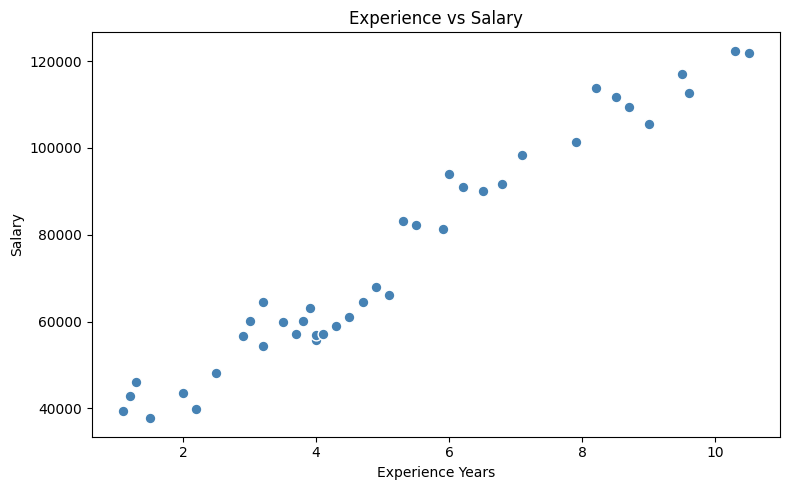

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', edgecolors='white', s=60)
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.tight_layout()
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [10]:
corr = df['Experience Years'].corr(df['Salary'])
print(f"Pearson correlation: {corr:.4f}")
print()
print("The relationship is INCREASING (strong positive correlation ~0.98).")
print("As experience increases, salary increases consistently.")

Pearson correlation: 0.9777

The relationship is INCREASING (strong positive correlation ~0.98).
As experience increases, salary increases consistently.


### Step 7. Initialize a regression model

In [11]:
model = LinearRegression()
print(model)

LinearRegression()


### Step 8. Split the dataset into train and test sets

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train samples: {X_train.shape[0]}")
print(f"Test  samples: {X_test.shape[0]}")

Train samples: 32
Test  samples: 8


### Step 9.a Train the model on the training set

In [13]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [14]:
slope = model.coef_[0]
intercept = model.intercept_
print(f"Slope (coef_):  {slope:.2f}")
print(f"Intercept:      {intercept:.2f}")
print(f"\nEquation: Salary = {slope:.2f} * Experience + {intercept:.2f}")

Slope (coef_):  9408.03
Intercept:      26716.25

Equation: Salary = 9408.03 * Experience + 26716.25


### Step 9.c how much salary does a person get with 2 years of experience?

In [15]:
pred_2yrs = model.predict(pd.DataFrame({'Experience Years': [2]}))
print(f"Predicted salary at 2 years of experience: ${pred_2yrs[0]:,.0f}")

Predicted salary at 2 years of experience: $45,532


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [16]:
increase_6mo = slope * 0.5
print(f"Salary increase per 6 months: ${increase_6mo:,.2f}")

Salary increase per 6 months: $4,704.02


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [17]:
print(f"Estimated salary at 0 years of experience: ${intercept:,.2f}")
print("(This is the y-intercept of the regression line.)")

Estimated salary at 0 years of experience: $26,716.25
(This is the y-intercept of the regression line.)


### Step 10. Evaluate the model on the test set

In [18]:
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"RMSE:     ${rmse:,.2f}")
print()
print(f"The model explains {r2*100:.1f}% of the variance in salary on unseen data.")

R² Score: 0.9069
RMSE:     $6,933.81

The model explains 90.7% of the variance in salary on unseen data.


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [19]:
sample_X = X_test.sample(3, random_state=1)
sample_preds  = model.predict(sample_X)
sample_actuals = y_test.loc[sample_X.index]

comparison = pd.DataFrame({
    'Experience Years': sample_X['Experience Years'].values,
    'Predicted Salary': sample_preds.round(0),
    'Actual Salary':    sample_actuals.values,
    'Error':            (sample_preds - sample_actuals.values).round(0)
})
comparison

,Experience Years,Predicted Salary,Actual Salary,Error
0,6.2,85046.0,91000,-5954.0
1,4.0,64348.0,55794,8554.0
2,4.0,64348.0,56957,7391.0


### Step 12. Plot the data and the regression line

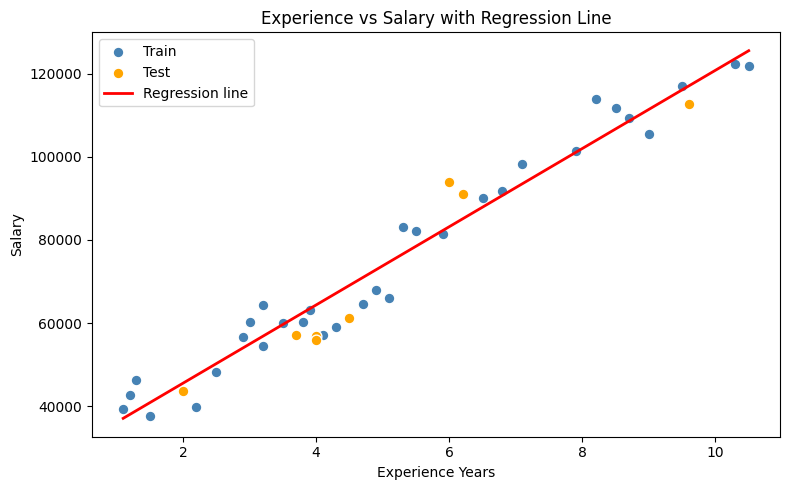

In [20]:
x_line = np.linspace(X['Experience Years'].min(), X['Experience Years'].max(), 100).reshape(-1, 1)
y_line = model.predict(pd.DataFrame(x_line, columns=['Experience Years']))

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='steelblue', edgecolors='white', s=60, label='Train')
plt.scatter(X_test,  y_test,  color='orange',    edgecolors='white', s=60, label='Test')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression line')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Experience vs Salary with Regression Line')
plt.legend()
plt.tight_layout()
plt.show()